# Earthdata GIS OPERA DSWx-HLS Image Service Access - Programmatic
<br>

Author(s): Nicholas Tarpinian, Brandi Downs, Catalina Taglialatela *(NASA PO.DAAC)*

_Created: 2026-06-01_ <br>
_Last Updated: 2026-06-29_ <br>



## Summary

This guide shows how to programmatically (**`Python`**) connect to, explore, and plot using the recently released NASA [**Earthdata GIS (EGIS)**](https://gis.earthdata.nasa.gov/portal/home/index.html) Image Service for Observational Products for End-Users from Remote Sensing Analysis (OPERA) Dynamic Surface Water eXtent (DSWx) Harmonized Landsat Sentinel-2 (HLS), namely the [OPERA_L3_DSWX-HLS_V1](https://www.earthdata.nasa.gov/data/catalog/pocloud-opera-l3-dswx-hls-v1-1.0) collection. **This allows users to interactively explore and visualize DSWx-HLS data directly from the Image Service without having to download and manage data files locally.**

Available EGIS services for OPERA DSWx-HLS at this time include:

- [OPERA_L3_DSWX-HLS_V1_B01_WTR](https://gis.earthdata.nasa.gov/portal/home/item.html?id=59caecb96b5b42dd85aa3001a10f7786) 

- [OPERA_L3_DSWX-HLS_V1_B03_CONF](https://gis.earthdata.nasa.gov/portal/home/item.html?id=f417d9093b714c06951f4c4bdf28e64e)

This tutorial focuses on the **B01_WTR** layer but a similar approach can be used with the **B03_CONF** layer.


For more details on these services and the latest available services, please visit the [EGIS OPERA Image Service page](https://gis.earthdata.nasa.gov/portal/home/group.html?id=780767a6cee24331baae8557c78d2e8a).

------

### Learning Objectives:
- **Programmatic Access:** Connect to and interact with the OPERA DSWx-HLS REST Image Service API from EGIS using Python.
- **Service Discovery:** Programmatically retrieve metadata and capabilities of the Image Service.
- **User Configuration:** Define your geographic area of interest, time range, and data fields.
- **Tabular Data Extraction:** Query the ArcGIS REST endpoint and parse the resulting Image Service metadata into a viewable table.
- **Interactive Exploration:** Visualize the selected tiles for your use case to get oriented and assess if sufficient data is available given your specified filtering.

### Import libraries

In [1]:
import requests
import json
import pandas as pd
import numpy as np
import folium
import xyzservices.providers as xyz
import base64
from IPython.display import display
from PIL import Image
from io import BytesIO

The OPERA EGIS Image Service endpoint can be queried through the ArcGIS REST endpoint. Find the URL of the service on the [content landing page](https://gis.earthdata.nasa.gov/portal/home/item.html?id=59caecb96b5b42dd85aa3001a10f7786), in the bottom right corner of the service landing page under `URL` as shown below:

<nop/> <div style="width: 700px;">![](../../images/EGIS_OPERA_Images/OPERA_EGIS_ArcGIS_1.png)</div>


### Helper Functions
We first define the following helper functions to handle time conversions, API requests, pagination, coordinate transformations, and scene validation.

- `to_epoch_ms`: When we search for a date like `"2025-01-01"`, the EGIS (ArcGIS) REST API cannot read this standard text format. This function translates our human-readable date into Unix Epoch Time (the number of milliseconds since January 1, 1970). This ensures we are speaking the exact numerical language the server's backend database requires.
- `get_json`: This function acts as a safety wrapper for requesting our data. It forces the server to return machine-readable JSON (instead of an HTML webpage) and enforces a 2-minute timeout to prevent your notebook from freezing on large queries. If the server encounters an error, it will raise a clear exception with the error message, making debugging easier.
- `query_all_features`: ArcGIS REST services often limit the number of records returned in a single request. This function automatically handles pagination by repeatedly requesting batches of results and combining them into a single list, ensuring all matching scenes are retrieved.
- `make_clickable`: Converts download URLs into clickable hyperlinks when displaying query results in a Pandas table.
- `scene_has_valid_data`: Determines whether an exported scene contains any valid pixels within the requested bounding box. This is used to remove scenes whose footprints intersect the AOI but whose valid raster data falls entirely outside the area of interest.

Most users only need to change the `URL=` in this code block when wishing to query a different EGIS REST API.

In [2]:
# Image Service URL
URL = "https://gis.earthdata.nasa.gov/image/rest/services/C2617126679-POCLOUD/OPERA_L3_DSWX-HLS_V1_B01_WTR/ImageServer"

def to_epoch_ms(date_str):
    """Converts a standard date string to Epoch milliseconds."""
    return int(pd.Timestamp(date_str, tz='UTC').timestamp() * 1000)

def get_json(url, params=None):
    """Sends a GET request and parses the JSON, with a 2-minute timeout for large queries."""
    p = dict(params or {})
    p.setdefault('f', 'json')
    r = requests.get(url, params=p, timeout=120)
    r.raise_for_status()
    data = r.json()
    if 'error' in data:
        raise RuntimeError(f"Server Error: {data['error']}")
    return data

# Retrieve all matching features by requesting results in batches and combining them into a single list.
# This is useful when a query returns more records than the server's maximum records-per-request limit. 
# For example, large spatial extents or long time series may contain thousands of scenes.
# The function uses pagination to retrieve all records.
def query_all_features(url, params, page_size=1000):
    """Query all records from an ArcGIS REST endpoint using pagination."""
    all_features = []
    offset = 0
    while True:
        p = dict(params)
        p["resultOffset"] = offset
        p["resultRecordCount"] = page_size
        data = get_json(url, params=p)
        features = data.get("features", [])
        all_features.extend(features)
        if len(features) < page_size:
            break
        offset += page_size
    return all_features

# Helper function to convert the string into an HTML link for Download Link
def make_clickable(val):
    if isinstance(val, str) and val.startswith("http"):
        return f'<a href="{val}" target="_blank">Download Granule</a>'
    return val

# Check whether an exported image contains any valid data pixels within the requested bounding box.
# In the exported image, pixels with no data values ('255' in the DSWx WTR dataset) are fully transparent (alpha=0).
def scene_has_valid_data(resp_content, min_valid_pixels=1):
    img = Image.open(BytesIO(resp_content)).convert("RGBA")
    alpha = np.asarray(img.getchannel("A"))
    valid_pixel_count = np.count_nonzero(alpha > 0)
    return valid_pixel_count >= min_valid_pixels

print("OPERA DSWx-HLS Image Service ready to query.")

OPERA DSWx-HLS Image Service ready to query.


### Information about the Image Service
Before querying the data, it is helpful to understand what the service provides. This block queries the service's base endpoint to retrieve the available metadata fields, server limits, and the total date range of the dataset. 


In [3]:
print("Grabbing Image Service Metadata...\n")

meta = get_json(URL)

print(f"Service name            : {meta.get('name')}")

# Available metadata fields:
fields = [f.get('name') for f in meta.get('fields', [])]
print(f"Available Fields        : {fields}")

# Server Limits (How big of an image can I request?)
max_h = meta.get('maxImageHeight')
max_w = meta.get('maxImageWidth')
print(f"Max Export Size         : {max_w} x {max_h} pixels")

# Capabilities (What can this API do?)
print(f"Service Capabilities    : {meta.get('capabilities')}")

# Time Info (What is the date range?)
time_info = meta.get('timeInfo', {})
start_ts = time_info.get('timeExtent', [0])[0]
end_ts = time_info.get('timeExtent', [0, 0])[1]
if start_ts:
    print(f"Dataset Starts          : {pd.to_datetime(start_ts, unit='ms')}")
    print(f"Dataset Ends            : {pd.to_datetime(end_ts, unit='ms')}")

Grabbing Image Service Metadata...

Service name            : C2617126679-POCLOUD/OPERA_L3_DSWX-HLS_V1_B01_WTR
Available Fields        : ['objectid', 'name', 'minps', 'maxps', 'lowps', 'highps', 'category', 'centerx', 'centery', 'shape', 'processingdate', 'tileid', 'datetime', 'productgenerationdatetime', 'cloud_coverage', 'spacecraft_name', 'downloadurl', 'urldisplay']
Max Export Size         : 2048 x 2048 pixels
Service Capabilities    : Catalog,Mensuration,Image,Metadata
Dataset Starts          : 2023-01-01 00:29:59
Dataset Ends            : 2026-06-17 23:56:09


(To learn more about image _Service Capabilities_, [see here](https://doc.esri.com/en/arcgis-enterprise/latest/administer/key-concepts-for-image-services.html?pivots=os-windows#:~:text=Details-,Imaging,-Always%20enabled.%20Allows").)


### User Configuration
**Define your search parameters here.** Adjust the Bounding Box (`BBOX`), date range (`START_DATE`, `END_DATE`), and maximum cloud coverage (`MAX_CLOUD_COVERAGE`) to target your specific Area of Interest (AOI) and use case. _Tip: You can use [bbox finder](http://bboxfinder.com/) to search for an area of interest coordinates._

In [4]:
# Define Area of Interest (xmin, ymin, xmax, ymax)
# For this example, we are using Lake Mead, USA
BBOX = "-114.90,35.90,-113.80,36.60" 

# Define Date Range (YYYY-MM-DD)
START_DATE = "2025-01-01"
END_DATE = "2025-01-10"

# Define maximum acceptable Cloud Coverage (Percentage)
MAX_CLOUD_COVERAGE = 10 

# Define specific fields from Availalbe Fields above to return in the table
FIELDS = "objectid,name,datetime,cloud_coverage,tileid,spacecraft_name,downloadurl"

### Query & Display Data Table
Using the parameters defined above, we will query the OPERA DSWx-HLS Image Service catalog.

In [5]:
# Set up the query parameters based on user configuration
query_params = {
    # Spatial Parameters
    'geometry': BBOX,                             # The actual coordinates of your search area
    'geometryType': 'esriGeometryEnvelope',       # Tells the server the coordinates for a rectangular Bounding Box
    'spatialRel': 'esriSpatialRelIntersects',     # Returns any image that touches or overlaps the bounding box
    'inSR': '4326',                               # Specifies our coordinates are in standard Lat/Lon (WGS84)
    
    # Attribute Filter Parameters
    'where': f"cloud_coverage <= {MAX_CLOUD_COVERAGE}",              # SQL-style filter to only keep scenes under our cloud limit
    'time': f"{to_epoch_ms(START_DATE)},{to_epoch_ms(END_DATE)}",    # Time window converted to Epoch milliseconds
    
    # Output Formatting Parameters
    'outFields': FIELDS,                          # The specific fields/columns we want returned (in our table)
    'returnGeometry': 'false',                    # Do not return the polygon/footprint shapefiles/geometry
    'orderByFields': 'datetime ASC',              # Sorts the final results chronologically (oldest to newest)
    'resultRecordCount': 2000                     # Limits the server to returning 2000 records at once to prevent timeouts
}

print("Querying the OPERA DSWx-HLS Catalog...")

# Execute the query
data = {"features": query_all_features(f"{URL}/query", query_params)}


# Parse the results into a Pandas DataFrame
if "features" in data and data["features"]:
    df = pd.DataFrame([f["attributes"] for f in data["features"]])

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], unit="ms")
    
    total_scenes = len(df)    
    print(f"Found {total_scenes} scenes matching your query.")

    # The ImageServer catalog query only tells us which scene footprints intersect the AOI. 
    # Some of those scenes may contain no valid pixels inside the AOI.
    # Request a small preview image for each scene and keep only scenes with
    # at least one valid pixel within the bounding box.
    valid_objectids = []
    for _, row in df.iterrows():
        objectid = row["objectid"]

        # Tell the server to export exactly one scene -- no mosaicking.
        # Without this mosaic rule, the ImageServer may combine or select among
        # overlapping scenes according to the service's default mosaic behavior.
        # Using esriMosaicLockRaster ensures that each exported image corresponds to 
        # exactly one ObjectID.
        mosaic_rule = json.dumps({
            "mosaicMethod": "esriMosaicLockRaster",
            "lockRasterIds": [int(objectid)]
        })

        img_params = {
            "bbox": BBOX,
            "bboxSR": "4326",    # Input bounding box is in geographic (lat/lon) coordinates
            "imageSR": "3857",   # Export the image in Web Mercator projection to display correctly on the map
            "size": "256,256",
            "format": "png32",
            "transparent": "true",
            "adjustAspectRatio": "false",   # Prevent ArcGIS from padding or changing the export extent to match the image size
            "mosaicRule": mosaic_rule,
            "f": "image"
        }

        resp = requests.get(f"{URL}/exportImage", params=img_params, timeout=120)

        if (
            resp.status_code == 200
            and resp.headers.get("Content-Type", "").startswith("image")
            and scene_has_valid_data(resp.content)
        ):
            valid_objectids.append(objectid)
        else:
            print(f"Removing objectid {objectid}: no valid data inside AOI")

    df = df[df["objectid"].isin(valid_objectids)].reset_index(drop=True)
    valid_scenes = len(df)

    print(f"{valid_scenes} scenes contain valid data within your bounding box.")
    print(f"{total_scenes - valid_scenes} scenes were excluded because all valid data falls outside the bounding box.")
    print("-" * 60)

    if "downloadurl" in df.columns:
        display(df.style.format({"downloadurl": make_clickable}))
    else:
        display(df)

else:
    print("No scenes found. Try expanding your date range, bounding box, or cloud coverage tolerance.")

Querying the OPERA DSWx-HLS Catalog...
Found 15 scenes matching your query.
Removing objectid 6268553: no valid data inside AOI
Removing objectid 6268557: no valid data inside AOI
Removing objectid 6297588: no valid data inside AOI
12 scenes contain valid data within your bounding box.
3 scenes were excluded because all valid data falls outside the bounding box.
------------------------------------------------------------


,objectid,name,datetime,cloud_coverage,tileid,spacecraft_name,downloadurl
0,6280533,OPERA_L3_DSWx-HLS_T12STF_20250104T182649Z_20250107T030638Z_S2B_30_v1.0_B01_WTR,2025-01-04 18:26:49,0,T12STF,Sentinel-2B,Download Granule
1,6280534,OPERA_L3_DSWx-HLS_T11SQA_20250104T182649Z_20250107T030637Z_S2B_30_v1.0_B01_WTR,2025-01-04 18:26:49,0,T11SQA,Sentinel-2B,Download Granule
2,6280536,OPERA_L3_DSWx-HLS_T11SPA_20250104T182649Z_20250107T030633Z_S2B_30_v1.0_B01_WTR,2025-01-04 18:26:49,2,T11SPA,Sentinel-2B,Download Granule
3,6280539,OPERA_L3_DSWx-HLS_T11SQV_20250104T182649Z_20250107T030643Z_S2B_30_v1.0_B01_WTR,2025-01-04 18:26:49,10,T11SQV,Sentinel-2B,Download Granule
4,6280541,OPERA_L3_DSWx-HLS_T11SPV_20250104T182649Z_20250107T030641Z_S2B_30_v1.0_B01_WTR,2025-01-04 18:26:49,4,T11SPV,Sentinel-2B,Download Granule
5,6302387,OPERA_L3_DSWx-HLS_T12STE_20250108T181539Z_20250113T211514Z_L8_30_v1.0_B01_WTR,2025-01-08 18:15:39,0,T12STE,Landsat-8,Download Granule
6,6308325,OPERA_L3_DSWx-HLS_T11SQA_20250109T182731Z_20250111T022843Z_S2A_30_v1.0_B01_WTR,2025-01-09 18:27:31,0,T11SQA,Sentinel-2A,Download Granule
7,6308326,OPERA_L3_DSWx-HLS_T12STF_20250109T182731Z_20250111T022849Z_S2A_30_v1.0_B01_WTR,2025-01-09 18:27:31,0,T12STF,Sentinel-2A,Download Granule
8,6308327,OPERA_L3_DSWx-HLS_T11SPA_20250109T182731Z_20250111T022845Z_S2A_30_v1.0_B01_WTR,2025-01-09 18:27:31,2,T11SPA,Sentinel-2A,Download Granule
9,6308330,OPERA_L3_DSWx-HLS_T12STE_20250109T182731Z_20250111T022845Z_S2A_30_v1.0_B01_WTR,2025-01-09 18:27:31,0,T12STE,Sentinel-2A,Download Granule


###  Visualize Individual Scenes on an Interactive Map

The following will allow you to view the individual scenes on an interactive map queried from the results above. Each scene can be toggled and viewed seperately.

Mapping 12 scenes...



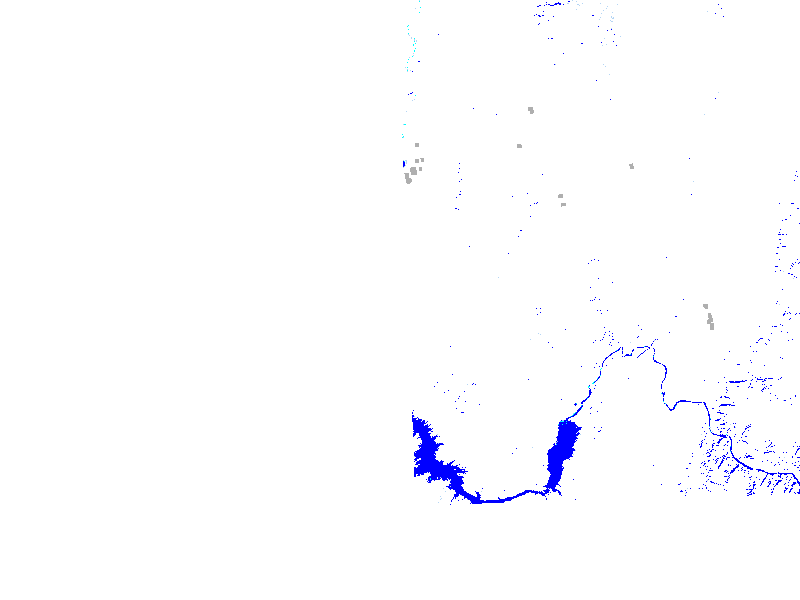
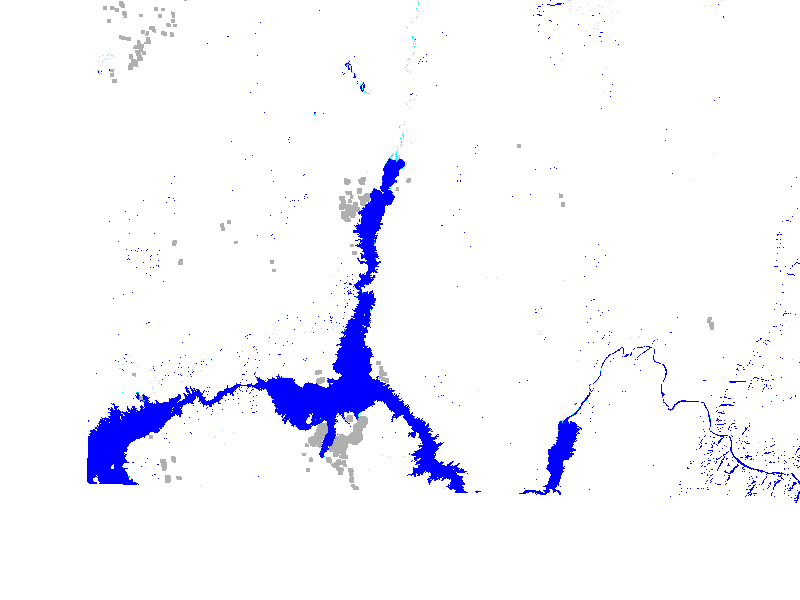
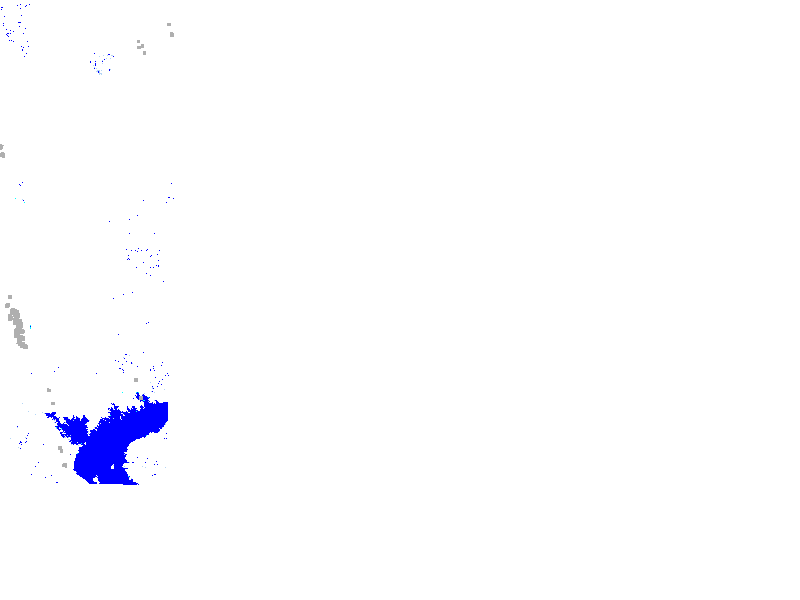
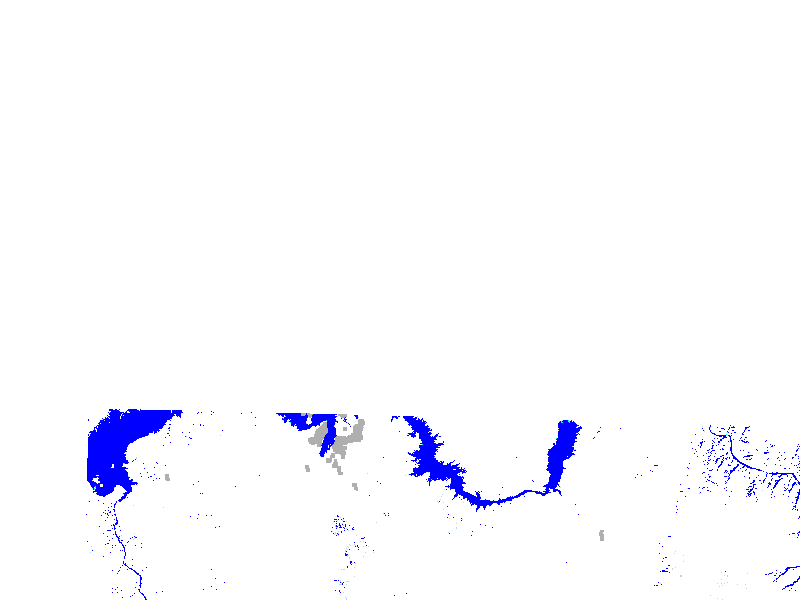
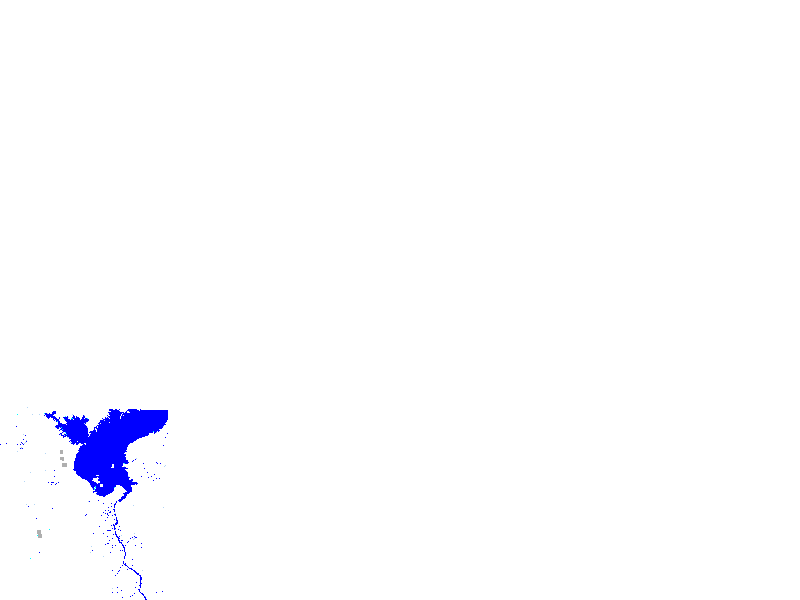
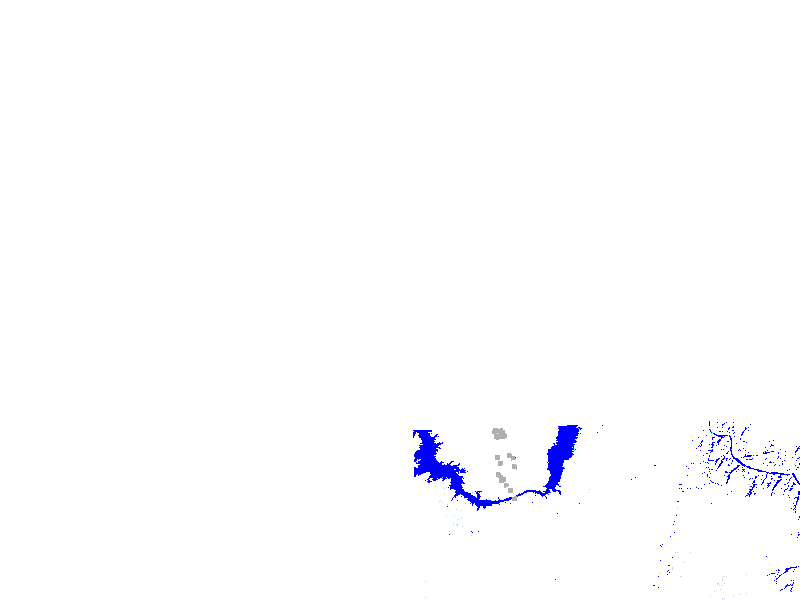
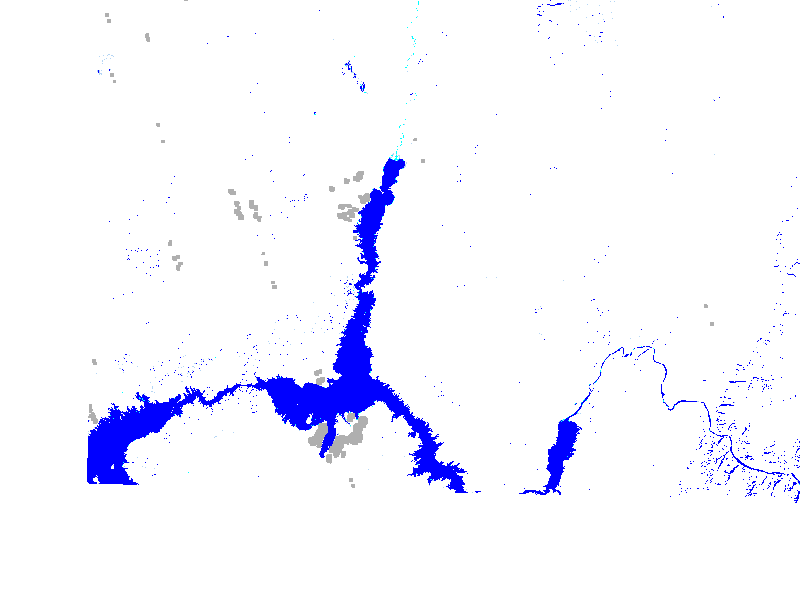
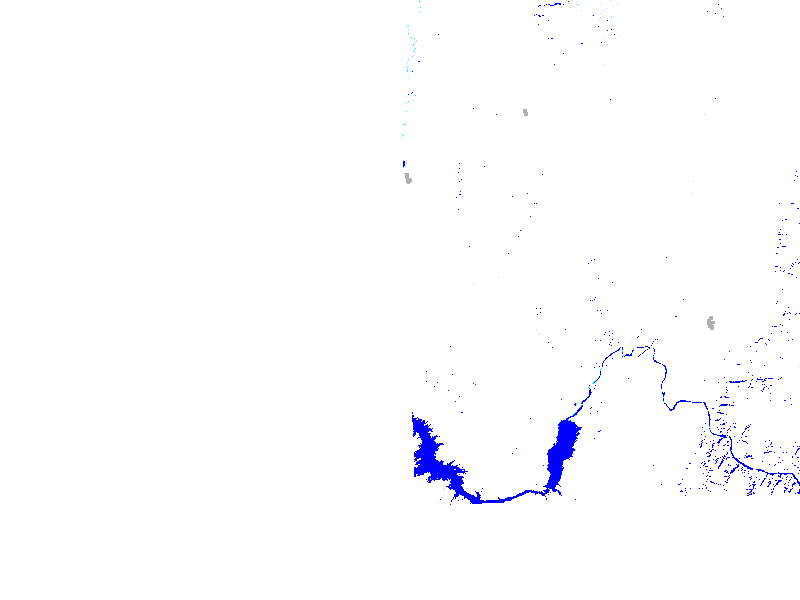
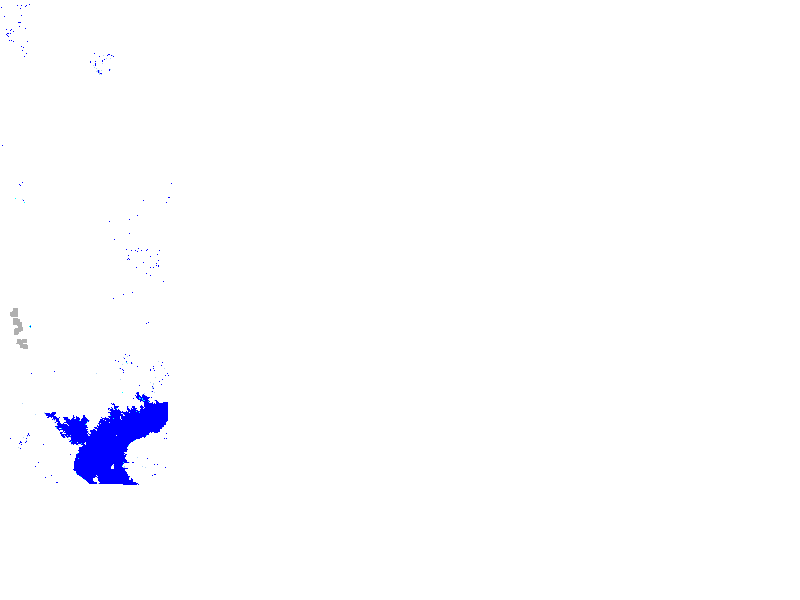
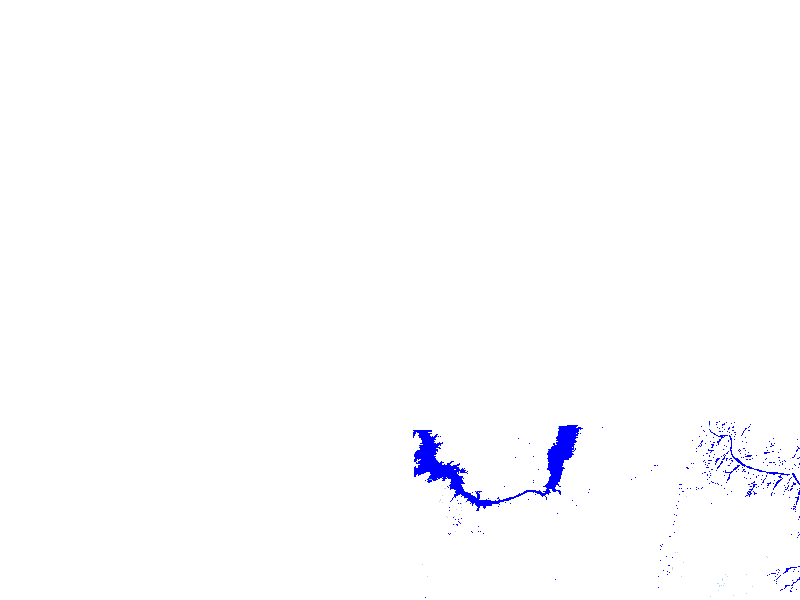
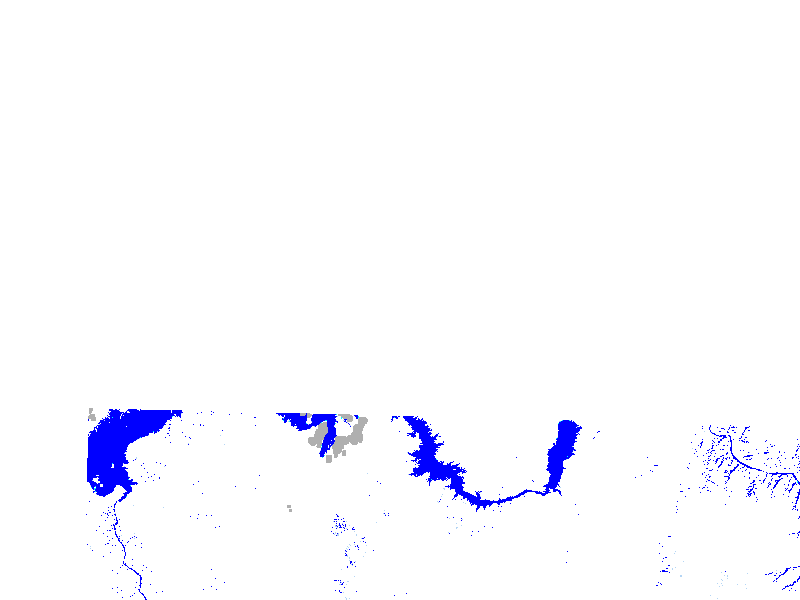
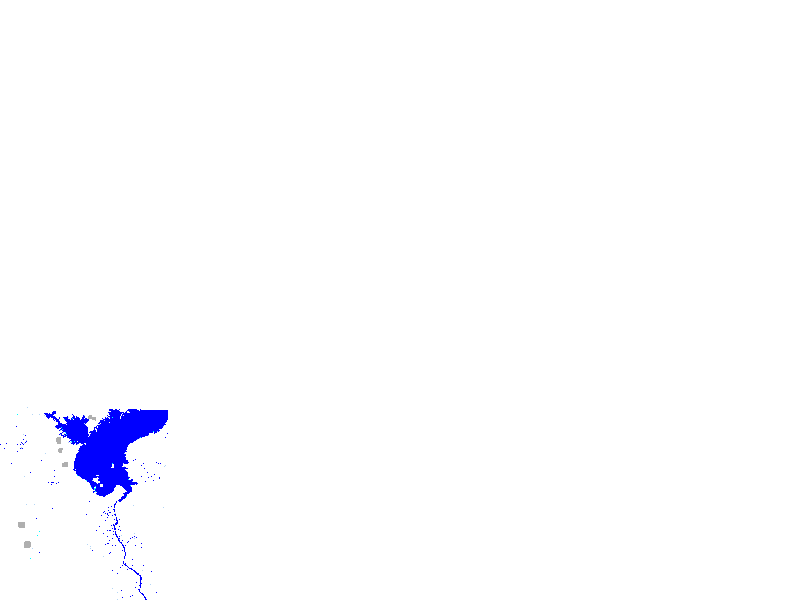

In [6]:
# Base Map Setup
xmin, ymin, xmax, ymax = map(float, BBOX.split(","))

m = folium.Map(
    location=[(ymin + ymax) / 2, (xmin + xmax) / 2],
    zoom_start=8,
    # tiles="OpenStreetMap"    # Standard street map basemap
    tiles="Cartodb Positron"   # Light, low-clutter basemap that emphasizes the DSWx layers
)

# OPTIONAL: Add a topographic tile layer
folium.TileLayer(
    xyz.OpenTopoMap.url,
    name='Topography',
    attr=xyz.OpenTopoMap.html_attribution
).add_to(m)

# AOI outline
folium.Rectangle(
    bounds=[[ymin, xmin], [ymax, xmax]],
    color="red",
    fill=False,
    name="AOI"
).add_to(m)

# DSWx legend
legend_html = """
<div style="
position: fixed;
bottom: 5px;
left: 5px;
width: 150px;
border:1px solid black;
z-index:9999;
background-color:white;
vertical-align:middle;
padding:3px;
font-size:10px;
">
<b>DSWx-HLS Classes</b><br>
<div><span style="display:inline-block;width:15px;height:15px;background:#ffffff;border:1px solid black;"></span> Not Water</div>
<div><span style="display:inline-block;width:15px;height:15px;background:#0000ff;border:1px solid black;"></span> Open Water</div>
<div><span style="display:inline-block;width:15px;height:15px;background:#b4d5f4;border:1px solid black;"></span> Partial Surface Water</div>
<div><span style="display:inline-block;width:15px;height:15px;background:#00ffff;border:1px solid black;"></span> HLS Snow/Ice</div>
<div><span style="display:inline-block;width:15px;height:15px;background:#afafaf;border:1px solid black;"></span> HLS Cloud/Cloud Shadow</div>
</div>
"""

# Query the server for scene records that match your criteria.
# This does not download or export imagery. It returns metadata records that are 
# used to identify which scenes should be exported and displayed on the map.
oid_params = {
    "geometry": BBOX,
    "geometryType": "esriGeometryEnvelope",
    "spatialRel": "esriSpatialRelIntersects",
    "inSR": "4326",    # Input bounding box is in geographic (lat/lon) coordinates
    "returnGeometry": "false",
    "where": f"cloud_coverage <= {MAX_CLOUD_COVERAGE}",
    "time": f"{to_epoch_ms(START_DATE)},{to_epoch_ms(END_DATE)}",
    "outFields": "objectid,name,datetime,spacecraft_name,cloud_coverage",
    "orderByFields": "datetime ASC"
}

feats = query_all_features(f"{URL}/query", oid_params)
valid_oid_set = set(df["objectid"])
feats = [f for f in feats if f["attributes"]["objectid"] in valid_oid_set]

print(f"Mapping {len(feats)} scenes...")

# Optional rendering rule.
# Apply the service's predefined WTR rendering so exported images
# use the same class of colors shown in Earthdata Search.
rendering_rule = json.dumps({
    "rasterFunction": "OPERA_L3_DSWX-HLS_V1_B01_WTR"
})

# Use AOI bounds for every overlay so images align correctly
map_bounds = [[ymin, xmin], [ymax, xmax]]

# Export each scene as a PNG image and read it into memory.
# The exported image is then added to the Folium map as an overlay.
# A separate export request is made for each scene because the
# mosaicRule changes for every objectid.
for feat in feats:
    attr = feat["attributes"]
    objectid = attr["objectid"]
    dt_str = pd.to_datetime(attr["datetime"], unit="ms").strftime("%Y-%m-%d")
    craft = attr.get("spacecraft_name", "Unknown")
    cloud_pct = attr.get("cloud_coverage", "N/A")
    layer_name = f"{dt_str} | {craft} | ☁ {cloud_pct}% | OID {objectid}"

    # Tell the server to export exactly one scene -- no mosaicking.
    # Without this mosaic rule, the ImageServer may combine or select among
    # overlapping scenes according to the service's default mosaic behavior.
    # Using esriMosaicLockRaster ensures that each exported image corresponds to 
    # exactly one ObjectID.
    mosaic_rule = json.dumps({
        "mosaicMethod": "esriMosaicLockRaster",
        "lockRasterIds": [objectid]
    })

    img_params = {
        "bbox": BBOX,
        "bboxSR": "4326",    # Input bounding box is in geographic (lat/lon) coordinates
        "imageSR": "3857",   # Export the image in Web Mercator projection to display correctly on the map
        "size": "800,600",
        "format": "png32",
        "transparent": "true",
        "adjustAspectRatio": "false",   # Prevent ArcGIS from padding or changing the export extent to match the image size
        "mosaicRule": mosaic_rule,
        "renderingRule": rendering_rule,
        "f": "image"
    }

    resp = requests.get(f"{URL}/exportImage", params=img_params, timeout=120)
    if resp.status_code == 200 and resp.headers.get("Content-Type", "").startswith("image"):
        b64_data = base64.b64encode(resp.content).decode("utf-8")

        folium.raster_layers.ImageOverlay(
            image=f"data:image/png;base64,{b64_data}",
            bounds=map_bounds,
            name=layer_name,
            opacity=0.75,
            show=False
        ).add_to(m)
    else:
        print(f"Could not map OID {objectid}: {resp.status_code}")
        print(resp.text[:300])

m.get_root().html.add_child(folium.Element(legend_html))   #OPTIONAL: Add legend to map
folium.LayerControl(collapsed=False).add_to(m)

display(m)

### Next Steps

This notebook introduced the fundamentals of accessing OPERA DSWx-HLS through the EGIS REST API.

For a science use case demonstrating **surface water extent time series analysis** using the EGIS REST API and OPERA DSWx-HLS, including raster export, mosaicking, quality filtering, and trend analysis, see [Earthdata GIS OPERA DSWx-HLS Science Use Case: Analyzing Surface Water Extent Change at Lake Mead](OPERA_EGIS_access_Python_LakeMead_timeseries.ipynb).